In [37]:
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy

In [2]:
aois = gpd.read_file("/home/jovyan/shared-public/deadtrees/deadwood/standing-deadwood-aerial-global-conservative_2026.06.17.gpkg", layer="aoi")
deadwood = gpd.read_file("/home/jovyan/shared-public/deadtrees/deadwood/standing-deadwood-aerial-global-conservative_2026.06.17.gpkg", layer="standing_deadwood")

In [3]:
deadwood_dataset_ids = aois.dataset_id.unique()

In [5]:
cover_subset = gpd.read_file(
    "/home/jovyan/shared-public/deadtrees/treecover/tree-cover-aerial-global_2026.06.17.gpkg", 
    layer="tree_cover", 
    engine="pyogrio",
    where=f"dataset_id IN ({', '.join(deadwood_dataset_ids.astype(str))})"
)

Criteria for including the dataset:
 - Mortality fraction is at least 10%
 - AOI area is at least 10000 m^2 (= 2 ecostress pixels)

In [8]:
aoi_area = aois.set_index("dataset_id").to_crs(8857).area

In [10]:
deadwood["geom_area"] = deadwood.to_crs(8857).geometry.area

In [11]:
cover_subset["geom_area"] = cover_subset.to_crs(8857).geometry.area

In [18]:
deadwood_area = deadwood.groupby("dataset_id").geom_area.sum()
cover_area    = cover_subset.groupby("dataset_id").geom_area.sum()

In [19]:
deadwood_area_align, cover_area_align = deadwood_area.align(cover_area, join="inner")
aoi_area_align = aoi_area.loc[deadwood_area_align.index]

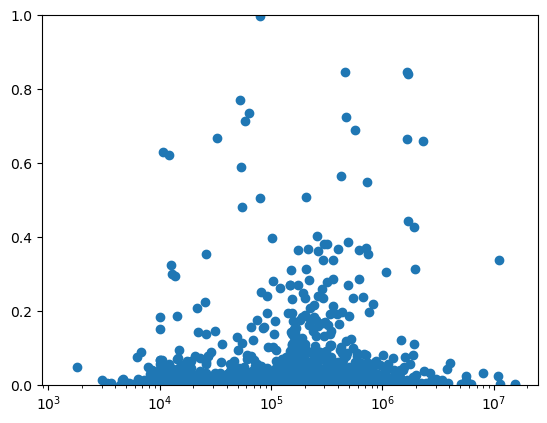

In [22]:
deadwood_fraction = deadwood_area_align / cover_area_align
plt.scatter(aoi_area_align, deadwood_fraction)
plt.xscale("log")
plt.ylim(0, 1)
plt.show()

In [25]:
ids_to_include = aoi_area[((aoi_area >= 1e4) & (deadwood_fraction >= 0.1))].index

In [26]:
ids_to_include

Index([  201,   211,   252,   264,   273,   275,   308,   314,   648,   720,
       ...
        6780,  6797,  6912,  7032,  7101,  7190,  7383,  7511,  7513, 10415],
      dtype='int64', name='dataset_id', length=158)

In [33]:
meta = pd.read_parquet("/home/jovyan/shared-public/deadtrees/treecover/METADATA.parquet").set_index("dataset_id").loc[ids_to_include]

In [34]:
meta["aoi_area"] = aoi_area_align
meta["deadwood_area"] = deadwood_area_align
meta["treecover_area"] = cover_area_align

In [35]:
aoi_gdf = gpd.GeoDataFrame(
    meta,
    geometry=aois.set_index("dataset_id").loc[ids_to_include].to_crs(8857).geometry
)

In [36]:
aoi_gdf.explore()

Split into subtrees for faster STAC querying later

In [43]:
cut_height = 10000
aoi_centroids = aoi_gdf.geometry.centroid.get_coordinates()
linkage = scipy.cluster.hierarchy.linkage(aoi_centroids, method="complete")
cuts = scipy.cluster.hierarchy.cut_tree(linkage, height=10000)
aoi_gdf["subtree"] = cuts[:, 0]

Visualize bounding box of each subtree

In [45]:
aoi_gdf.dissolve(by="subtree").geometry.envelope.explore()

In [46]:
aoi_gdf.to_file("../data_working/deadtrees_aoi.gpkg")